# Online Discussion of #OscarSoWhite
- This notebook contains an analysis of the sentiment behind tweets with the #OscarsSoWhite hashtag. 

## Twitter Analysis

In [1]:
import ast
from IPython.display import display, clear_output
import json
from ipywidgets import widgets, VBox, HBox, Button, Label, Output
import pandas as pd
import pyktok as pyk
import random
from openai import OpenAI
import seaborn as sns
import matplotlib.pyplot as plt

from dotenv import load_dotenv

_ = load_dotenv()

If pyktok does not operate as expected, you may find it helpful to run the 'specify_browser' function. 'specify_browser' takes as its sole argument a string representing a browser installed on your system, e.g. "chrome," "firefox," "edge," etc.


In [2]:
client = OpenAI()

In [3]:
df = pd.read_csv('oscarssowhite_tweets_2015-2022.csv')

sample_df = df.sample(n=100, random_state=42).reset_index(drop=True)
text_col = 'text'

for col in ['coder1_concept1', 'coder1_concept2', 'coder2_concept1', 'coder2_concept2']:
    sample_df[col] = None

In [15]:
concept1 = "Code 1 if the tweet supports or amplifies the #OscarsSoWhite movement, criticizes the lack of racial diversity at the Oscars, or expresses solidarity with underrepresented groups. Code 0 for everything else."

concept2 = "Code 1 if the tweet opposes, criticizes, or dismisses the #OscarsSoWhite movement, defends the Academy's choices, does not support racial diversity, or ridicules those calling out the lack of diversity. Code 0 for everything else."

In [17]:
main_out = Output()
coder1_out = Output()

def code_entries(coder_label, concept1_col, concept2_col, container_out):
    index = 0
    text_label = Label(value=sample_df.loc[index, text_col])
    concept1_toggle = widgets.ToggleButtons(options=[0, 1], description='Concept 1:')
    concept2_toggle = widgets.ToggleButtons(options=[0, 1], description='Concept 2:')
    next_button = Button(description='Next →', button_style='success')
    progress = Label(value=f"{coder_label}: {index + 1}/{len(sample_df)}")

    def next_entry(_):
        nonlocal index
        sample_df.loc[index, concept1_col] = concept1_toggle.value
        sample_df.loc[index, concept2_col] = concept2_toggle.value
        index += 1
        if index < len(sample_df):
            text_label.value = sample_df.loc[index, text_col]
            concept1_toggle.value = None
            concept2_toggle.value = None
            progress.value = f"{coder_label}: {index + 1}/{len(sample_df)}"
        else:
            container_out.clear_output()
            with container_out:
                display(Label(value=f"{coder_label} has finished coding! ✅"))
            with main_out:
                print("✅ Coder finished. Saving data...")
                sample_df.to_csv('coded_data.csv', index=False)
                print("💾 Coded data saved to coded_data.csv")

    next_button.on_click(next_entry)
    with container_out:
        container_out.clear_output()
        display(VBox([progress, text_label, concept1_toggle, concept2_toggle, next_button]))

# ---- Workflow ----
print(f"Support: {concept1}")
print(f"Anti: {concept2}\n")
print("=== Coder: Please start coding ===")
code_entries("Coder", "coder1_concept1", "coder1_concept2", coder1_out)
display(coder1_out, main_out)

Support: Code 1 if the tweet supports or amplifies the #OscarsSoWhite movement, criticizes the lack of racial diversity at the Oscars, or expresses solidarity with underrepresented groups. Code 0 for everything else.
Anti: Code 1 if the tweet opposes, criticizes, or dismisses the #OscarsSoWhite movement, defends the Academy's choices, does not support racial diversity, or ridicules those calling out the lack of diversity. Code 0 for everything else.

=== Coder: Please start coding ===


Output()

Output()

In [7]:
sample_df.to_csv('coded_data.csv', index=False)
print("💾 Coded data saved to coded_data.csv")

💾 Coded data saved to coded_data.csv


## LLM coding of tweets for two concepts

In [5]:
LLM_prompt = '''You are a social-science research assistant helping code tweets for a content analysis study on #OscarsSoWhite.

For Concept 1:
Code "1" if the tweet supports or amplifies the #OscarsSoWhite movement, criticises the lack of racial diversity at the Oscars, expresses solidarity with underrepresented groups, or praises diverse nominees/films. Code "0" for everything else.

For Concept 2:
Code "1" if the tweet opposes, mocks, or dismisses the #OscarsSoWhite movement, defends the Academy's choices as merit-based, or ridicules those calling out the lack of diversity. Code "0" for everything else.

Important Clarification Rules for both concepts:
A comment can receive two zeros if it supports neither side.
If a comment is ambiguous, vague, or does not explicitly take a stance, code both concepts as 0.
Retweets (starting with "RT @") should be coded the same as original tweets.
A tweet may NOT be coded 1 for both concepts simultaneously.
Do not infer meaning beyond what is written. When in doubt, code 0.
'''

In [6]:
batch_size = 50

def ai_code_batch(text_list):
    texts_formatted = "\n".join([f"{i+1}. {t}" for i, t in enumerate(text_list)])
    
    prompt = f"""
        {LLM_prompt}
        
        You will receive {len(text_list)} texts.
        
        Return ONLY valid JSON — a list of {len(text_list)} dictionaries like this:
        
        [
          {{"concept1": 1, "concept2": 0}},
          ...
        ]
        
        No explanations, no comments, no extra text — only the JSON array.
        
        Texts:
        {texts_formatted}
        """

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )

    try:
        output_text = response.choices[0].message.content.strip()
        batch_json = json.loads(output_text)
        return batch_json  
    except Exception as e:
        try:
            print("Trying to parse")
            s = output_text.replace("```", "").replace("json", "").replace("\n", "").strip()
            lst = json.loads(s)
            print("✅ Parsed successfully.")
            return lst
        except Exception as e:
            print("⚠️ Parsing error:", e)
            return [{"concept1": None, "concept2": None} for _ in text_list]

In [11]:
# !! Change file name !!
tweets = pd.read_csv("../data/oscarssowhite_tweets_2015-2022.csv")
# comments = comments.head(100)

ai_concept1, ai_concept2 = [], []

text_col = 'extended_full_text'


for start in range(0, len(tweets), batch_size):
    print(f"Beginning coding round {(start/batch_size) + 1}")
    end = start + batch_size
    batch_texts = tweets[text_col].iloc[start:end].tolist()
    batch_results = ai_code_batch(batch_texts)

    for r in batch_results:
        ai_concept1.append(r.get("concept1"))
        ai_concept2.append(r.get("concept2"))

# Add results to dataframe
tweets["ai_concept1"] = ai_concept1
tweets["ai_concept2"] = ai_concept2

# Save to file
tweets.to_csv("final_coded_data.csv", index=False)
print("✅ Finished Coding!")

Beginning coding round 1.0
Trying to parse
✅ Parsed successfully.
Beginning coding round 2.0
Trying to parse
✅ Parsed successfully.
Beginning coding round 3.0
Trying to parse
✅ Parsed successfully.
Beginning coding round 4.0
Trying to parse
✅ Parsed successfully.
Beginning coding round 5.0
Trying to parse
✅ Parsed successfully.
Beginning coding round 6.0
Trying to parse
✅ Parsed successfully.
Beginning coding round 7.0
Trying to parse
✅ Parsed successfully.
Beginning coding round 8.0
Trying to parse
✅ Parsed successfully.
Beginning coding round 9.0
Trying to parse
✅ Parsed successfully.
Beginning coding round 10.0
Trying to parse
✅ Parsed successfully.
Beginning coding round 11.0
Trying to parse
✅ Parsed successfully.
Beginning coding round 12.0
Trying to parse
✅ Parsed successfully.
Beginning coding round 13.0
Trying to parse
✅ Parsed successfully.
Beginning coding round 14.0
Trying to parse
✅ Parsed successfully.
Beginning coding round 15.0
Trying to parse
✅ Parsed successfully.
Begi

ValueError: Length of values (12692) does not match length of index (11724)

In [13]:
len(ai_concept1)

12692

In [14]:
len(ai_concept2)

12692

In [18]:
coded_concepts_df = pd.DataFrame({'ai_concept1': ai_concept1, 'ai_concept2': ai_concept2})

In [19]:
coded_concepts_df.to_csv('ai_concepts_coded.csv', index=False)

In [20]:
tweets.shape

(11724, 63)

In [21]:
len(tweets)

11724

In [24]:
len(batch_results)

26

In [25]:
tweets["ai_concept1"] = ai_concept1[:len(tweets)]
tweets["ai_concept2"] = ai_concept2[:len(tweets)]

# Save to file
tweets.to_csv("final_coded_data.csv", index=False)
print("✅ Finished Coding!")

✅ Finished Coding!


### Analysis from Entire Dataset

In [6]:
def collapse(x):
    if x.coder1_concept1 == 1:
        return "concept1"
    elif x.coder1_concept2 == 1:
        return "concept2"
    else:
        return "neither"

In [7]:
sample_coded_data = pd.read_csv('coded_data.csv')

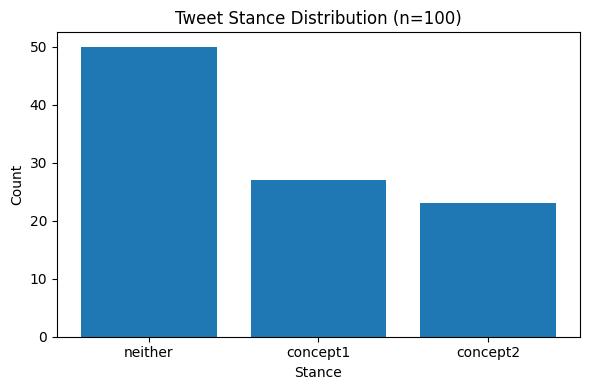

In [19]:


sample_coded_data['collapsed_codes'] = sample_coded_data.apply(collapse, axis=1)

counts = sample_coded_data['collapsed_codes'].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values)
plt.title("Tweet Stance Distribution (n=100)")
plt.xlabel("Stance")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

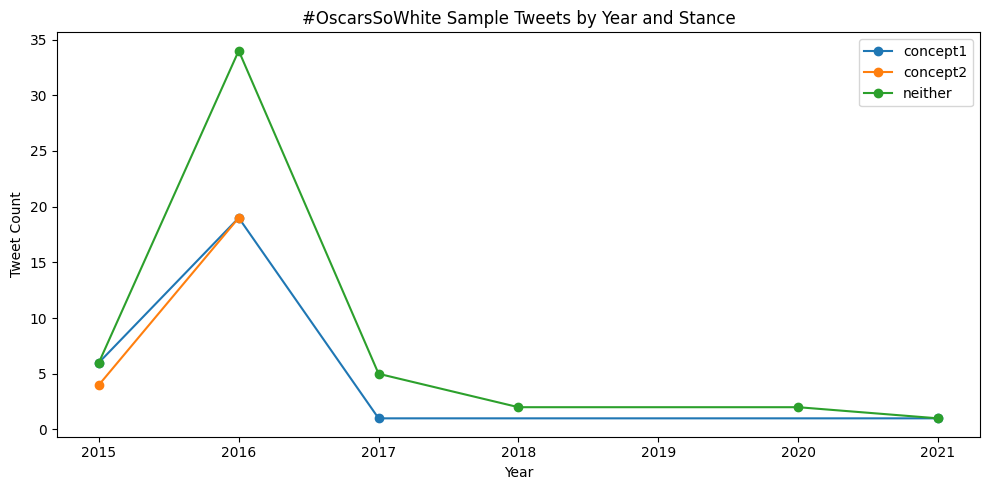

In [25]:
time_series = (
   sample_coded_data.groupby(['year', 'collapsed_codes'])
    .size()
    .reset_index(name='count')
)

fig, ax = plt.subplots(figsize=(10, 5))
for stance, grp in time_series.groupby('collapsed_codes'):
    ax.plot(grp['year'], grp['count'], marker='o', label=stance)

ax.set_title("#OscarsSoWhite Sample Tweets by Year and Stance")
ax.set_xlabel("Year")
ax.set_ylabel("Tweet Count")
ax.legend()
plt.tight_layout()
plt.show()

### Analysis from fulled coded tweets

In [8]:
def collapse(x):
    if x.ai_concept1 == 1:
        return "concept1"
    elif x.ai_concept2 == 1:
        return "concept2"
    else:
        return "neither"

In [9]:
final_coded_data = pd.read_csv('final_coded_data.csv')

/tmp/ipykernel_635138/3297696322.py:1: DtypeWarning: Columns (0: user_verified, 1: truncated, 2: is_quote_status, 3: favorited, 4: retweeted, 5: filter_level, 6: possibly_sensitive, 7: rt_user_verified, 8: rt_user_location, 9: rt_truncated, 10: rt_source) have mixed types. Specify dtype option on import or set low_memory=False.
  final_coded_data = pd.read_csv('final_coded_data.csv')


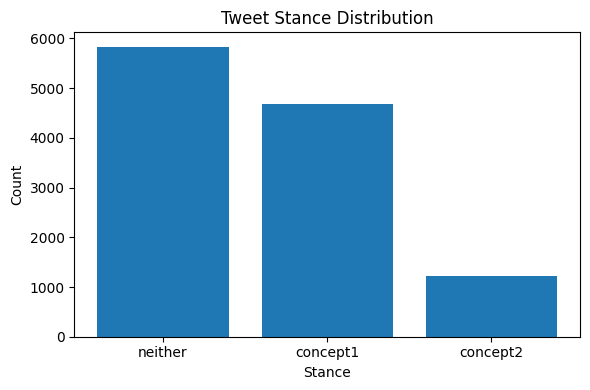

In [10]:
final_coded_data['collapsed_codes'] = final_coded_data.apply(collapse, axis=1)

counts = final_coded_data['collapsed_codes'].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values)
plt.title("Tweet Stance Distribution")
plt.xlabel("Stance")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

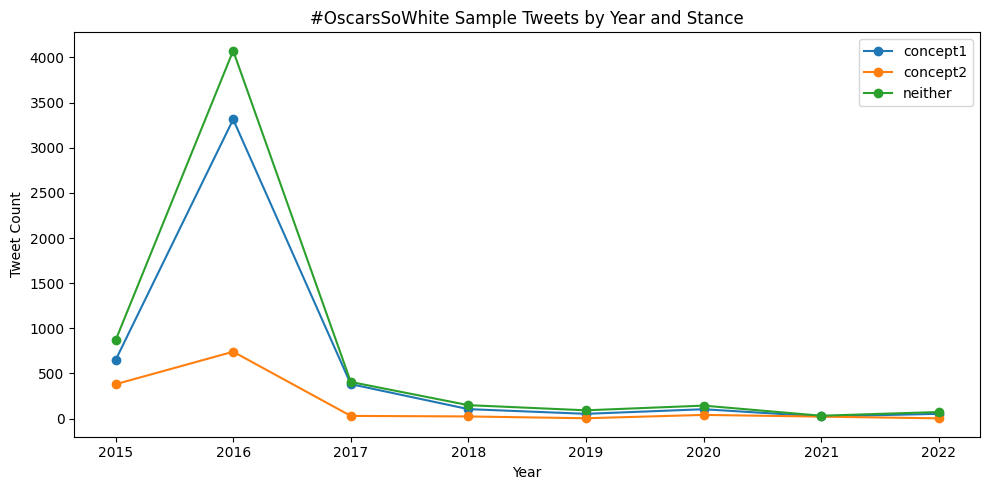

In [34]:
time_series = (
   final_coded_data.groupby(['year', 'collapsed_codes'])
    .size()
    .reset_index(name='count')
)

fig, ax = plt.subplots(figsize=(10, 5))
for stance, grp in time_series.groupby('collapsed_codes'):
    ax.plot(grp['year'], grp['count'], marker='o', label=stance)

ax.set_title("#OscarsSoWhite Sample Tweets by Year and Stance")
ax.set_xlabel("Year")
ax.set_ylabel("Tweet Count")
ax.legend()
plt.tight_layout()
plt.show()

### Creating more tailored concpets

In [3]:
LLM_prompt = '''You are a social-science research assistant helping code tweets for a content analysis study on #OscarsSoWhite.

For Concept 1:
Code "1" if the tweet has a neutral stance on the #OscarsSoWhite movement. Specifically, if the tweet is from a news report that has a neutral stance and is simply reporting on the topic. Code "0" for everything else.

For Concept 2:
Code "1" if the tweet is a spam post, with unreadable letters, words, emojis, or symbols. Also, code "1" if you can not read a retweet. Code "0" for everything else.

For Concept 3:
Code "1" if the tweet expresses that the #OscarsSoWhite movement is exclusionary and leaves out Asian, Hispanic, or other marginalized people. Code "0" for everything else.

For Concept 4:
Code "1" if the tweet claims the #OscarsSoWhite movement forces the Academy to choose race over merit, the movement undermines talent in the Oscars, and further critism of the hashtag. Code "1" if the tweet argues that the #OscarsSoWhite movement is itself racist or racially biased — for example, by invoking double standards (e.g., comparing it to the BET Awards), claiming the hashtag discriminates against white people, or framing diversity advocacy as anti-white. Code "0" for everything else.

For Concept 5:
Code "1" if the tweet frames the lack of Oscar diversity as a systemic or structural problem rooted in how Hollywood operates — for example, by pointing to industry-wide whiteness, historical patterns of exclusion, or the need for institutional change. Code "0" for everything else.

For Concept 6: 
Code "1" if the tweet uses sarcasm, irony, or humor to critique the lack of Oscar diversity — for example, jokes about the all-white nominee slate, mock award categories, or sardonic comparisons. Code "0" for everything else.

For Concept 7:
Code "1" if the tweet generally supports or amplifies the #OscarsSoWhite movement, criticises the lack of racial diversity at the Oscars, expresses solidarity with underrepresented groups, or praises diverse nominees/films. Code "0" for everything else.

For Concept 7:
Code "1" if the tweet generally opposes, mocks, or dismisses the #OscarsSoWhite movement, defends the Academy's choices as merit-based, or ridicules those calling out the lack of diversity. Code "0" for everything else.


Important Clarification Rules for both concepts:
A comment can receive two zeros if it supports neither side.
If a comment is ambiguous, vague, or does not explicitly take a stance, code both concepts as 0.
Retweets (starting with "RT @") should be coded the same as original tweets.
A tweet may NOT be coded 1 for both concepts simultaneously.
Do not infer meaning beyond what is written. When in doubt, code 0.
'''

In [4]:
batch_size = 50

def ai_code_batch(text_list):
    texts_formatted = "\n".join([f"{i+1}. {t}" for i, t in enumerate(text_list)])
    
    prompt = f"""
        {LLM_prompt}
        
        You will receive {len(text_list)} texts.
        
        Return ONLY valid JSON — a list of {len(text_list)} dictionaries like this:
        
        [
          {{"concept_1": 1, "concept_2": 0, "concept_3": 0, "concept_4": 0, "concept_5": 0, "concept_6": 0, "concept_7": 0, "concept_8": 0}},
          ...
        ]
        
        No explanations, no comments, no extra text — only the JSON array.
        
        Texts:
        {texts_formatted}
        """
    
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    
    null_row = {f"concept_{i}": None for i in range(1, 9)}
    
    try:
        output_text = response.choices[0].message.content.strip()
        batch_json = json.loads(output_text)
        return batch_json
    except Exception as e:
        try:
            print("Trying to parse...")
            s = output_text.replace("```", "").replace("json", "").replace("\n", "").strip()
            lst = json.loads(s)
            print("✅ Parsed successfully.")
            return lst
        except Exception as e:
            print("⚠️ Parsing error:", e)
            return [null_row for _ in text_list]

In [ ]:
# !! Change file name !!
tweets = pd.read_csv("../data/oscarssowhite_tweets_2015-2022.csv")
# tweets = tweets.head(100)

ai_concepts = {f"concept_{i}": [] for i in range(1, 9)}
text_col = 'extended_full_text'

for start in range(0, len(tweets), batch_size):
    end = start + batch_size
    batch_texts = tweets[text_col].iloc[start:end].tolist()
    batch_results = ai_code_batch(batch_texts)
    for r in batch_results:
        for i in range(1, 9):
            ai_concepts[f"concept_{i}"].append(r.get(f"concept_{i}"))

for i in range(1, 9):
    tweets[f"ai_concept_{i}"] = ai_concepts[f"concept_{i}"]

# Save to file
tweets.to_csv("final_coded_allconcepts.csv", index=False)
print("✅ Finished Coding!")

Trying to parse...
✅ Parsed successfully.
Trying to parse...
✅ Parsed successfully.


In [9]:
pd.DataFrame(ai_results)

,concept_1,concept_2,concept_3,concept_4,concept_5,concept_6,concept_7,concept_8
0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0
4,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
234,0,0,0,0,0,0,0,0
235,0,0,0,0,0,0,0,0
236,0,0,0,0,0,0,0,0
237,0,0,0,0,0,0,0,0


In [10]:
sample_df = tweets.loc[:238]

In [12]:
testset = pd.concat([sample_df, pd.DataFrame(ai_results)], axis=1)

In [13]:
testset.to_csv('testing_new_concepts.csv', index=False)